# Evaluating spectral separability

This notebook can be used to evaluate spectral separability of point-spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

### Set-up 
importing modules and data

In [45]:
# Import required scripts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import speca.label_data as sld
import speca.plot_data as spd
import speca.resampling as srs

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [181]:
# Import data from .csv
path = r".\data\MEL_NZ_TAS_spectra.csv"
data = pd.read_csv(path)

## Pre-process data

In [182]:
# Create and preview labels for various grouping schemes

labels = sld.label_the_data(data)
#labels.to_csv(r".\data\MEL_NZ_TAS_labels.csv", index=False)

## Prepare data for plotting

In [177]:
# Define data formatting and filtering parameters:
scheme = "all" # "kelp", "browns", "farm"
target_sites = ["new_zealand", "melbourne", "tasmania"]
target_setup = ["handheld"]
bad_bands_list = map(str,list(range(753, 769)))

In [178]:
# Format the data
formatted_data = spd.format_for_plotting(data, labels, bad_bands_list)

# Filter to targets of interest
filtered_labels, filtered_data = spd.filter_for_plotting(formatted_data, labels, scheme = "all", target_setup = ["handheld"], target_sites= target_sites)

# Crop out noisy wavelengths
cropped_data = spd.crop_noisy_wavelengths(filtered_data, "400", "900")

# Scale the data
scaled_data = spd.scale_data(cropped_data, "standard")

# Calculate the class specific stats
class_stats_dict = spd.class_stats(scaled_data, filtered_labels, grouping = "Class", plot_by_site= False)

# # OR run prepping chain
# results = spd.prepping_chain(data, labels)

In [168]:
# Choose what to plot
search_words = ['acrocarpia',
                'cystophora',
                'carpophyllum',
                'durvillaea',
                'hormosira',
                'phyllospora',
                'sargassum',
                'scytosiphon']
search_sites = []

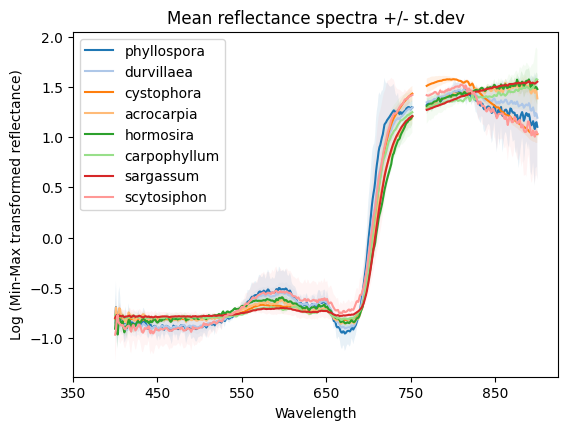

In [179]:
#Call the plotting function according to the desired search words, mode, bad bands
spd.plot_search_terms(search_words, search_sites, any, class_stats_dict, start_wavelength= 400)

## Preprocessing the reflectance spectra

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes 
If a scaler is chosen, it will scale the data accordingly.

In [156]:
import speca.preprocessing as prep
import speca.visualizing as sv

In [146]:
# Define preprocessing parameters
path = r"C:\Users\s4770224\Documents\coding\Spectral_analysis\Combined_analysis\MEL_NZ_TAS_spectra.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "standard"
target_scheme = "all"
target_sites = None
target_setup = None
start_nm = 400
end_nm = 900

In [147]:
#Run the preprocessing chain
prepper = prep.PreprocessRefl(data_path = path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra
labels_prepped = prepper.labels

Data filtered from 388 to 388 spectra.


## Visualise the prepared reflectance spectra 

Import and initialize the plotting class using the already defined parameters from preprocessing.

In [157]:
# Initialize visualizer with existing parameters
vizer = sv.Visualizer(spectra_prepped, 
                      labels_prepped, 
                      start_nm, 
                      end_nm)

# Calculate class statistics for plotting
vizer.class_stats(grouping="Class", 
                  plot_by_site = True)

### Chose spectra to plot

Search words below defines what target types you want to plot. Search sites is optional, but will let you chose to plot spectra from only the specified site(s). The mode parameter can be `any` or `all` to indicate if all of the search terms need to be met or if all must be found to be returned.

In [158]:
search_words = ["macrocystis",
                "rock",]
search_sites = "melbourne"
mode = any

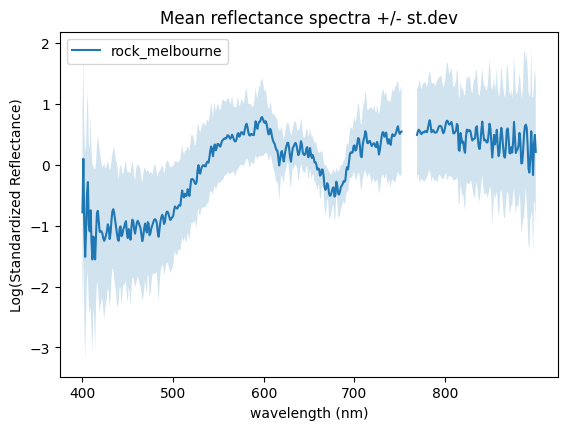

In [159]:
vizer.plot_search_terms(search_words= search_words, mode = any, search_sites = search_sites)

# Hierarchical Cluster Analysis